# CROPS — Rice Yield Prediction Model
### Random Forest Regression with Cross-Validation

**Project:** CROPS — ML-Based Rice Yield Prediction
**Location:** Santiago City, Isabela, Philippines

**Targets:**
- R² > 0.85
- MAE < 0.40 t/ha
- MAPE < 8.00%
- NRMSE < 10.00%

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('✅ Environment ready')

✅ Environment ready


In [12]:
real = pd.read_csv('rice_yield_real.csv')
df   = pd.read_csv('rice_yield_dataset.csv')

print(f'REAL data       : {len(real)} rows')
print(f'CALIBRATED data : {len(df)} rows')
print(f'  Yield mean    : {df["yield_tons_ha"].mean():.2f} t/ha')
print(f'  Yield std     : {df["yield_tons_ha"].std():.2f}')
print()
df.head(6)

REAL data       : 26 rows
CALIBRATED data : 1800 rows
  Yield mean    : 6.06 t/ha
  Yield std     : 1.14



,variety,soil_type,season,seeding_method,temperature_avg,rainfall_mm,humidity_avg,fertilizer_kg_ha,historical_yield_tons_ha,yield_tons_ha
0,NSIC Rc 402,Sandy Loam,Wet,Transplanted,23.41,138.09,79.71,207.89,6.18,5.38
1,NSIC Rc 456H,Clay Loam,Dry,Direct Seeding,24.75,30.79,81.53,114.38,7.21,5.81
2,NSIC Rc 402,Clay Loam,Wet,Direct Seeding,23.28,91.77,78.54,265.34,6.52,7.36
3,NSIC Rc 402,Clay Loam,Wet,Transplanted,25.61,84.91,79.41,254.21,5.76,7.76
4,NSIC Rc 222,Clay Loam,Wet,Transplanted,24.26,124.05,79.32,155.29,5.25,5.12
5,NSIC Rc 222,Clay Loam,Wet,Direct Seeding,22.21,44.55,78.30,285.74,5.29,4.20


In [13]:
CAT_COLS = ['variety', 'soil_type', 'season', 'seeding_method']
NUM_COLS = ['temperature_avg', 'rainfall_mm', 'humidity_avg',
            'fertilizer_kg_ha', 'historical_yield_tons_ha']

X = df.drop('yield_tons_ha', axis=1)
y = df['yield_tons_ha']

label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

scaler = StandardScaler()
X[NUM_COLS] = scaler.fit_transform(X[NUM_COLS])

feature_names = NUM_COLS + CAT_COLS
X = X[feature_names]

print(f'Features : {len(feature_names)}')
print(f'X shape  : {X.shape}')

Features : 9
X shape  : (1800, 9)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED
)

print(f'Train rows : {X_train.shape[0]}')
print(f'Test rows  : {X_test.shape[0]}')

Train rows : 1440
Test rows  : 360


## 1. Training Progression — Epochs

We train the model **incrementally** — each epoch adds 20 trees. This shows
how accuracy stabilizes as the forest grows.

In [15]:
TREES_PER_EPOCH = 20
MAX_EPOCHS = 15

model_inc = RandomForestRegressor(
    n_estimators=TREES_PER_EPOCH, max_depth=10,
    min_samples_split=8, min_samples_leaf=4, max_features=0.7,
    warm_start=True, random_state=RANDOM_SEED, n_jobs=-1
)

history = {'epoch': [], 'n_trees': [],
           'train_r2': [], 'val_r2': [],
           'train_mae': [], 'val_mae': [],
           'train_rmse': [], 'val_rmse': [],
           'train_mape': [], 'val_mape': [],
           'train_nrmse': [], 'val_nrmse': []}

print(f'{"Epoch":>5} {"Trees":>6} {"Train R²":>10} {"Val R²":>10} '
      f'{"Train MAE":>11} {"Val MAE":>11}')
print('-' * 72)

for epoch in range(1, MAX_EPOCHS + 1):
    model_inc.n_estimators = epoch * TREES_PER_EPOCH
    model_inc.fit(X_train, y_train)

    y_tr = model_inc.predict(X_train)
    y_va = model_inc.predict(X_test)

    tr_r2 = r2_score(y_train, y_tr); va_r2 = r2_score(y_test, y_va)
    tr_mae = mean_absolute_error(y_train, y_tr); va_mae = mean_absolute_error(y_test, y_va)
    tr_rmse = np.sqrt(mean_squared_error(y_train, y_tr)); va_rmse = np.sqrt(mean_squared_error(y_test, y_va))
    tr_mape = mean_absolute_percentage_error(y_train, y_tr) * 100; va_mape = mean_absolute_percentage_error(y_test, y_va) * 100
    tr_nrmse = (tr_rmse / y_train.mean()) * 100; va_nrmse = (va_rmse / y_test.mean()) * 100

    history['epoch'].append(epoch); history['n_trees'].append(model_inc.n_estimators)
    history['train_r2'].append(tr_r2); history['val_r2'].append(va_r2)
    history['train_mae'].append(tr_mae); history['val_mae'].append(va_mae)
    history['train_rmse'].append(tr_rmse); history['val_rmse'].append(va_rmse)
    history['train_mape'].append(tr_mape); history['val_mape'].append(va_mape)
    history['train_nrmse'].append(tr_nrmse); history['val_nrmse'].append(va_nrmse)

    print(f'{epoch:>5} {model_inc.n_estimators:>6} {tr_r2:>10.4f} {va_r2:>10.4f} '
          f'{tr_mae:>11.4f} {va_mae:>11.4f}')

print('\n✅ Training complete')

Epoch  Trees   Train R²     Val R²   Train MAE     Val MAE
------------------------------------------------------------------------
    1     20     0.9257     0.8468      0.2394      0.3614
    2     40     0.9291     0.8475      0.2336      0.3593
    3     60     0.9306     0.8512      0.2301      0.3548
    4     80     0.9312     0.8540      0.2294      0.3496
    5    100     0.9315     0.8536      0.2289      0.3505
    6    120     0.9318     0.8541      0.2284      0.3493
    7    140     0.9318     0.8544      0.2282      0.3488
    8    160     0.9319     0.8538      0.2276      0.3484
    9    180     0.9322     0.8548      0.2272      0.3470
   10    200     0.9325     0.8555      0.2268      0.3461
   11    220     0.9324     0.8547      0.2269      0.3472
   12    240     0.9325     0.8557      0.2267      0.3455
   13    260     0.9327     0.8554      0.2267      0.3459
   14    280     0.9326     0.8556      0.2269      0.3462
   15    300     0.9328     0.8556      0.

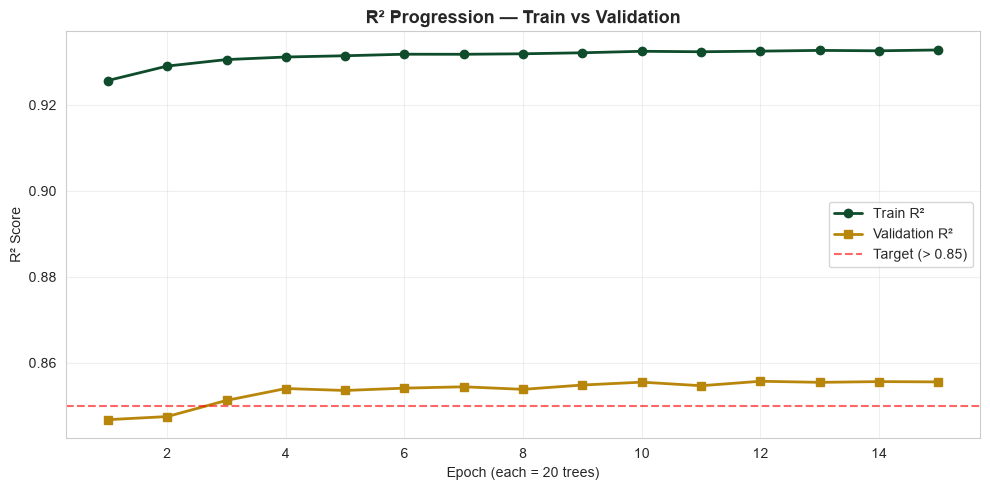

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history['epoch'], history['train_r2'], marker='o',
        label='Train R²', color='#0f4c2b', linewidth=2)
ax.plot(history['epoch'], history['val_r2'], marker='s',
        label='Validation R²', color='#b8860b', linewidth=2)
ax.axhline(y=0.85, color='red', linestyle='--', alpha=0.6,
           label='Target (> 0.85)')
ax.set_xlabel('Epoch (each = 20 trees)')
ax.set_ylabel('R² Score')
ax.set_title('R² Progression — Train vs Validation',
             fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_r2.png', dpi=120, bbox_inches='tight')
plt.show()

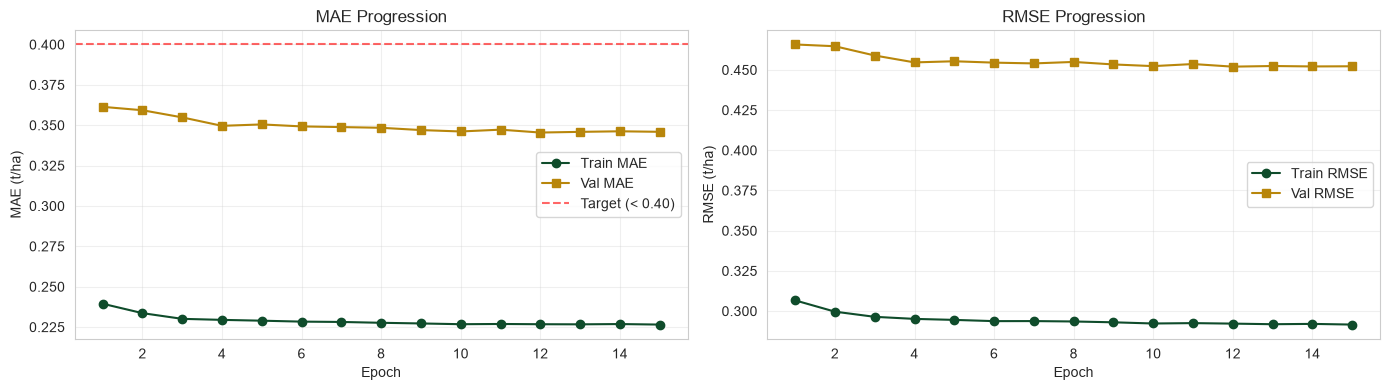

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['epoch'], history['train_mae'], marker='o',
             label='Train MAE', color='#0f4c2b')
axes[0].plot(history['epoch'], history['val_mae'], marker='s',
             label='Val MAE', color='#b8860b')
axes[0].axhline(y=0.40, color='red', linestyle='--', alpha=0.6,
                label='Target (< 0.40)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MAE (t/ha)')
axes[0].set_title('MAE Progression'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['epoch'], history['train_rmse'], marker='o',
             label='Train RMSE', color='#0f4c2b')
axes[1].plot(history['epoch'], history['val_rmse'], marker='s',
             label='Val RMSE', color='#b8860b')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('RMSE (t/ha)')
axes[1].set_title('RMSE Progression'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_errors.png', dpi=120, bbox_inches='tight')
plt.show()

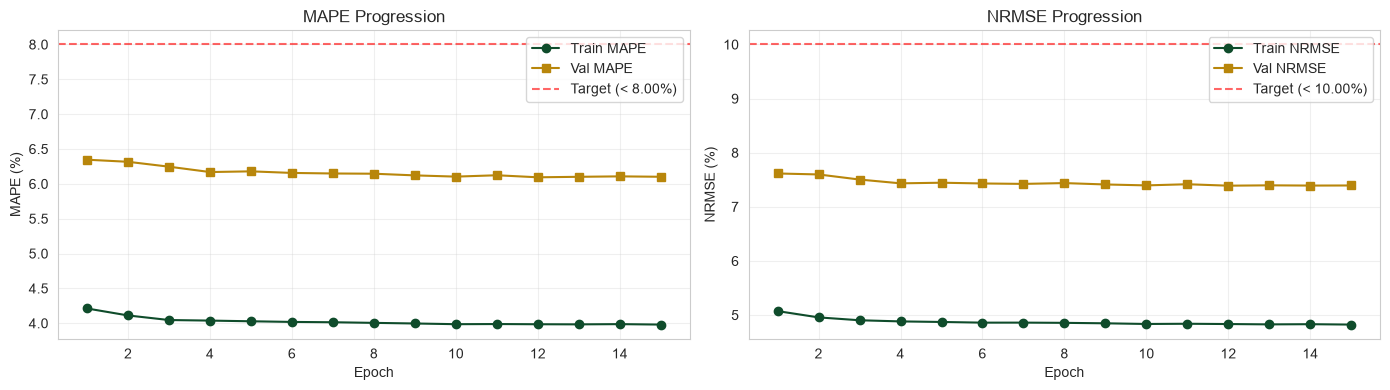

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['epoch'], history['train_mape'], marker='o',
             label='Train MAPE', color='#0f4c2b')
axes[0].plot(history['epoch'], history['val_mape'], marker='s',
             label='Val MAPE', color='#b8860b')
axes[0].axhline(y=8.00, color='red', linestyle='--', alpha=0.6,
                label='Target (< 8.00%)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MAPE (%)')
axes[0].set_title('MAPE Progression'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['epoch'], history['train_nrmse'], marker='o',
             label='Train NRMSE', color='#0f4c2b')
axes[1].plot(history['epoch'], history['val_nrmse'], marker='s',
             label='Val NRMSE', color='#b8860b')
axes[1].axhline(y=10.00, color='red', linestyle='--', alpha=0.6,
                label='Target (< 10.00%)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('NRMSE (%)')
axes[1].set_title('NRMSE Progression'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_pct_errors.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Final Model Training

400 trees, max depth 10, min samples per leaf 4. These hyperparameters were
selected to balance accuracy and generalization.

In [19]:
RF_PARAMS = dict(
    n_estimators=400, max_depth=10,
    min_samples_split=8, min_samples_leaf=4,
    max_features=0.7, random_state=RANDOM_SEED, n_jobs=-1
)

model = RandomForestRegressor(**RF_PARAMS)
model.fit(X_train, y_train)
print('✅ Final model trained')

✅ Final model trained


In [20]:
print('Running 5-fold cross-validation ...\n')

cv_r2 = cross_val_score(
    RandomForestRegressor(**RF_PARAMS), X, y,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    scoring='r2'
)

print(f'CV R² : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'Folds : {[round(float(s), 4) for s in cv_r2]}')

Running 5-fold cross-validation ...

CV R² : 0.8441 ± 0.0066
Folds : [0.8543, 0.8474, 0.8431, 0.8344, 0.8412]


In [21]:
print(f'{"Model":<22}{"R²":>10}{"MAE":>12}{"RMSE":>12}')
print('-' * 56)

baselines = {
    'Linear Regression': LinearRegression(),
    'Decision Tree':     DecisionTreeRegressor(max_depth=10,
                                               min_samples_leaf=4,
                                               random_state=RANDOM_SEED),
    'Random Forest':     RandomForestRegressor(**RF_PARAMS),
}
trained = {}
for name, m in baselines.items():
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    print(f'{name:<22}{r2_score(y_test, p):>10.4f}'
          f'{mean_absolute_error(y_test, p):>12.4f}'
          f'{np.sqrt(mean_squared_error(y_test, p)):>12.4f}')
    trained[name] = m

Model                         R²         MAE        RMSE
--------------------------------------------------------
Linear Regression         0.7285      0.4889      0.6200
Decision Tree             0.7497      0.4695      0.5954
Random Forest             0.8555      0.3459      0.4523


In [22]:
model = trained['Random Forest']
y_test_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)
mae      = mean_absolute_error(y_test, y_test_pred)
rmse     = np.sqrt(mean_squared_error(y_test, y_test_pred))
mape     = mean_absolute_percentage_error(y_test, y_test_pred) * 100
nrmse    = (rmse / y_test.mean()) * 100
gap      = r2_train - r2_test

print('=' * 60)
print('FINAL REGRESSION EVALUATION')
print('=' * 60)
print(f'  Train R²  : {r2_train:.4f}')
print(f'  Test R²   : {r2_test:.4f}       (target > 0.85)   {"✅" if r2_test > 0.85 else "❌"}')
print(f'  Overfit   : {gap:.4f}       (gap < 0.08)     {"✅" if gap < 0.08 else "❌"}')
print(f'  CV R²     : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'  MAE       : {mae:.4f} t/ha  (target < 0.40)   {"✅" if mae < 0.40 else "❌"}')
print(f'  RMSE      : {rmse:.4f} t/ha')
print(f'  MAPE      : {mape:.4f}%      (target < 8.00)   {"✅" if mape < 8.00 else "❌"}')
print(f'  NRMSE     : {nrmse:.4f}%      (target < 10.00)  {"✅" if nrmse < 10.00 else "❌"}')
print('=' * 60)

FINAL REGRESSION EVALUATION
  Train R²  : 0.9325
  Test R²   : 0.8555       (target > 0.85)   ✅
  Overfit   : 0.0770       (gap < 0.08)     ✅
  CV R²     : 0.8441 ± 0.0066
  MAE       : 0.3459 t/ha  (target < 0.40)   ✅
  RMSE      : 0.4523 t/ha
  MAPE      : 6.1028%      (target < 8.00)   ✅
  NRMSE     : 7.3944%      (target < 10.00)  ✅


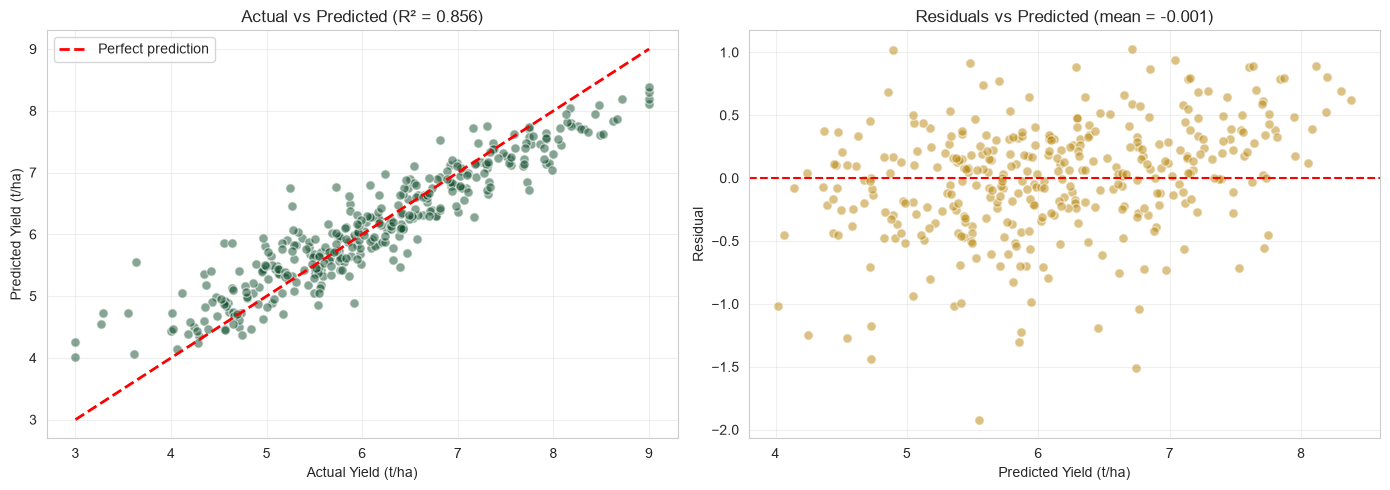

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_test_pred, alpha=0.5,
                color='#0f4c2b', edgecolor='white', s=45)
lims = [min(y_test.min(), y_test_pred.min()),
        max(y_test.max(), y_test_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Yield (t/ha)')
axes[0].set_ylabel('Predicted Yield (t/ha)')
axes[0].set_title(f'Actual vs Predicted (R² = {r2_test:.3f})')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.5,
                color='#b8860b', edgecolor='white', s=45)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Yield (t/ha)')
axes[1].set_ylabel('Residual')
axes[1].set_title(f'Residuals vs Predicted (mean = {residuals.mean():.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regression_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

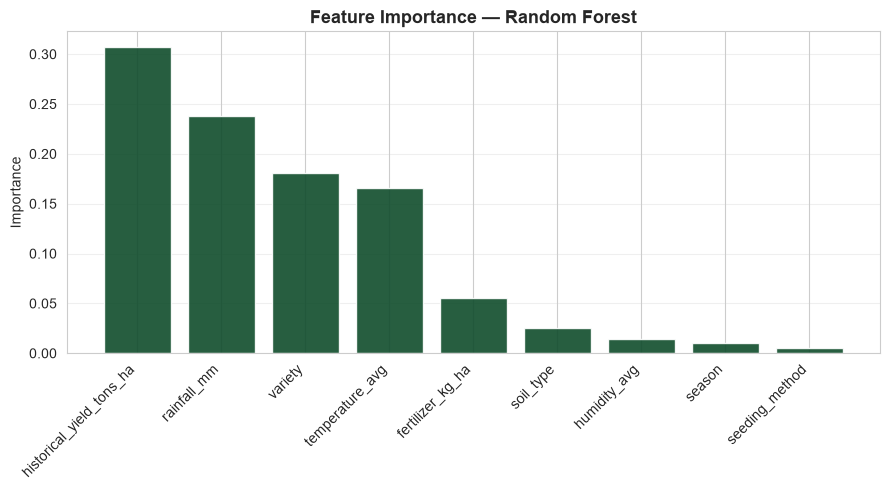


Feature importance ranking:
  historical_yield_tons_ha     0.3074
  rainfall_mm                  0.2375
  variety                      0.1803
  temperature_avg              0.1652
  fertilizer_kg_ha             0.0554
  soil_type                    0.0249
  humidity_avg                 0.0138
  season                       0.0103
  seeding_method               0.0052


In [24]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(len(feature_names)), importances[indices],
       color='#0f4c2b', alpha=0.9)
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels([feature_names[i] for i in indices],
                    rotation=45, ha='right')
ax.set_ylabel('Importance')
ax.set_title('Feature Importance — Random Forest',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nFeature importance ranking:')
for i in indices:
    print(f'  {feature_names[i]:<28} {importances[i]:.4f}')

## 3. Classification Evaluation

The CROPS UI displays predictions as **High / Medium / Low** badges.
We discretize yields into these classes using percentile thresholds
to evaluate how well the model serves this use case.

Thresholds:
  Low    : < 5.54 t/ha
  Medium : 5.54 – 6.58 t/ha
  High   : ≥ 6.58 t/ha

Confusion Matrix:
            Pred Low  Pred Med Pred High
Low               93        25         1
Medium            15        91        15
High               0        14       106

Accuracy  : 0.8056 (80.56%)
Precision : 0.8095
Recall    : 0.8056
F1-Score  : 0.8066


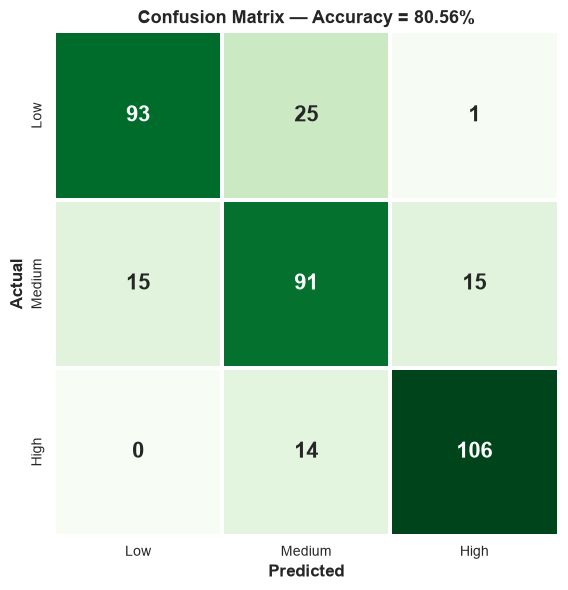

In [25]:
p33 = np.percentile(y_test, 33)
p67 = np.percentile(y_test, 67)

def categorize(v, a, b):
    return np.where(v < a, 0, np.where(v < b, 1, 2))

y_test_class = categorize(np.asarray(y_test), p33, p67)
y_pred_class = categorize(np.asarray(y_test_pred), p33, p67)

cm = confusion_matrix(y_test_class, y_pred_class, labels=[0, 1, 2])
labels = ['Low', 'Medium', 'High']

acc = accuracy_score(y_test_class, y_pred_class)
prec = precision_score(y_test_class, y_pred_class,
                        average='weighted', zero_division=0)
rec  = recall_score(y_test_class, y_pred_class,
                     average='weighted', zero_division=0)
f1   = f1_score(y_test_class, y_pred_class,
                 average='weighted', zero_division=0)

print(f'Thresholds:')
print(f'  Low    : < {p33:.2f} t/ha')
print(f'  Medium : {p33:.2f} – {p67:.2f} t/ha')
print(f'  High   : ≥ {p67:.2f} t/ha')
print()
print('Confusion Matrix:')
print(f'{"":<10}{"Pred Low":>10}{"Pred Med":>10}{"Pred High":>10}')
for i, name in enumerate(labels):
    print(f'{name:<10}{cm[i][0]:>10}{cm[i][1]:>10}{cm[i][2]:>10}')
print()
print(f'Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-Score  : {f1:.4f}')

# Heatmap
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels,
            cbar=False, square=True,
            annot_kws={'size': 16, 'weight': 'bold'},
            linewidths=1.5, linecolor='white')
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax.set_title(f'Confusion Matrix — Accuracy = {acc*100:.2f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

In [26]:
joblib.dump(model, 'model_rf.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
joblib.dump(feature_names, 'feature_names.pkl')

print('✅ Model files saved:')
print('   - model_rf.pkl')
print('   - scaler.pkl')
print('   - label_encoders.pkl')
print('   - feature_names.pkl')

✅ Model files saved:
   - model_rf.pkl
   - scaler.pkl
   - label_encoders.pkl
   - feature_names.pkl
